In [115]:
import numpy as np
from skimage.feature import local_binary_pattern
from scipy.stats import itemfreq
import math
import cv2

import numpy as np
import matplotlib.pyplot as plt

def local_ternary_pattern(image, num_points, radius, threshold):

    h, w = image.shape
    
    # Initialize LTP output array
    ltp = np.zeros((h-2*radius, w-2*radius, num_points))
    
    for i in range(radius, h-radius):
        for j in range(radius, w-radius):
        
            # Empty array to store neighbor values
            neigh_vals = np.zeros(num_points)  
            
            # Extract neighbor values
            for k in range(num_points):
                theta = 2*np.pi*k/num_points
                x = i + radius*np.cos(theta)
                y = j - radius*np.sin(theta)
                
                x = int(round(x))
                y = int(round(y))
                
                neigh_vals[k] = image[x,y]
                
            # Compute ternary pattern            
            centre = image[i,j]        
            ternary_pattern = ""
            
            for val in neigh_vals:
                if val >= centre + threshold:
                    ternary_pattern += "1"
                elif val <= centre - threshold:
                    ternary_pattern += "0"
                else:
                    ternary_pattern += "-"
            
            # Store pattern in LTP array
            #print(np.shape(ltp),np.shape(ternary_pattern))
            #ltp[i-radius, j-radius, :] = np.array(ternary_pattern)
                    
            mapping = {'1': 1, '0': 0, '-': 2}

            # Convert patterns to integers
            for i in range(ltp.shape[0]):
                for j in range(ltp.shape[1]):
                    pattern = ltp[i,j,:]
                    pattern_int = [mapping[x] for x in ternary_pattern]
                    ltp[i,j,:] = np.array(pattern_int)
            return ltp

def extract_lbp_features(img):
    radius = 1 
    n_points = 8 * radius
    lbp = local_binary_pattern(img, n_points, radius, method='default')
    n_bins = int(lbp.max() + 1)
    hist, _ = np.histogram(lbp, density=True, bins=n_bins, range=(0, n_bins))
    return hist

def extract_ltp_features(img):
    radius = 1
    n_points = 241 *radius  
    ltp = local_ternary_pattern(img, n_points, radius,0.1)
    (hist_up, _) = np.histogram(ltp[:, :, 0], bins=n_points+1) 
    (hist_down, _) = np.histogram(ltp[:, :, 1], bins=n_points+1)
    hist = np.concatenate((hist_up, hist_down))
    return hist

def extract_wld_features(img):
    m, n = img.shape
    img = img.astype(np.float32)
    hist = np.zeros((256, 256))
    for i in range(1, m-1):
        for j in range(1, n-1):
            cx = img[i, j]
            x = np.matrix([[img[i-1, j-1], img[i-1, j], img[i-1, j+1]], 
                           [img[i, j-1], 0, img[i, j+1]],
                           [img[i+1, j-1], img[i+1, j], img[i+1, j+1]]])

            orient = math.atan2(x[1, 2]-x[1, 0], x[2, 1]-x[0, 1])
            orient_bin = int(orient / (2*math.pi) * 9)

            diff_excit = cx - x.max()
            diff_excit_bin = int(diff_excit / 256 * 9)

            hist[orient_bin, diff_excit_bin] += 1
            
    hist /= hist.sum()
    return hist.ravel()
  
img = cv2.imread('C:/Users/Administrator/Downloads/Sample.jpg')[:,:,0] #load image
  
lbp_features = extract_lbp_features(img)
ltp_features = extract_ltp_features(img)  
wld_features = extract_wld_features(img)
np.shape(lbp_features),np.shape(ltp_features)[0],np.shape(wld_features),np.shape(img)


((256,), 484, (65536,), (510, 510))

In [114]:

def extract_ltp_features(img,n):
    radius = 1
    n_points = n *radius  
    ltp = local_ternary_pattern(img, n_points, radius,0.1)
    (hist_up, _) = np.histogram(ltp[:, :, 0], bins=n_points+1) 
    (hist_down, _) = np.histogram(ltp[:, :, 1], bins=n_points+1)
    hist = np.concatenate((hist_up, hist_down))
    return hist

for i in range(200,400):
    ltp_features = extract_ltp_features(img,i)
    if np.sqrt(np.shape(ltp_features)[0])%1==0:
        print(i)
        break
    

241


In [122]:
from skimage.color import gray2rgb
from skimage.transform import resize

lbp = extract_lbp_features(img)
ltp = extract_ltp_features(img)
wld = extract_wld_features(img)

# Get original image size
img_h, img_w = img.shape[:2]

# Reshape features to image dimensions
lbp_map = lbp.reshape(16,16) 
ltp_map = ltp.reshape(22,22)
wld_map = wld.reshape(256,256)

# Normalize maps between 0-1 
lbp_map = (lbp_map - np.min(lbp_map)) / (np.max(lbp_map) - np.min(lbp_map))
ltp_map = (ltp_map - np.min(ltp_map)) / (np.max(ltp_map) - np.min(ltp_map)) 
wld_map = (wld_map - np.min(wld_map)) / (np.max(wld_map) - np.min(wld_map))

# Resize to original dims 
lbp_map = resize(lbp_map, (img_h, img_w), anti_aliasing=True)
ltp_map = resize(ltp_map, (img_h, img_w), anti_aliasing=True)
wld_map = resize(wld_map, (img_h, img_w), anti_aliasing=True)

# Convert grayscale maps to RGB for visualization
#lbp_map = gray2rgb(lbp_map)
#ltp_map = gray2rgb(ltp_map)
#wld_map = gray2rgb(wld_map)


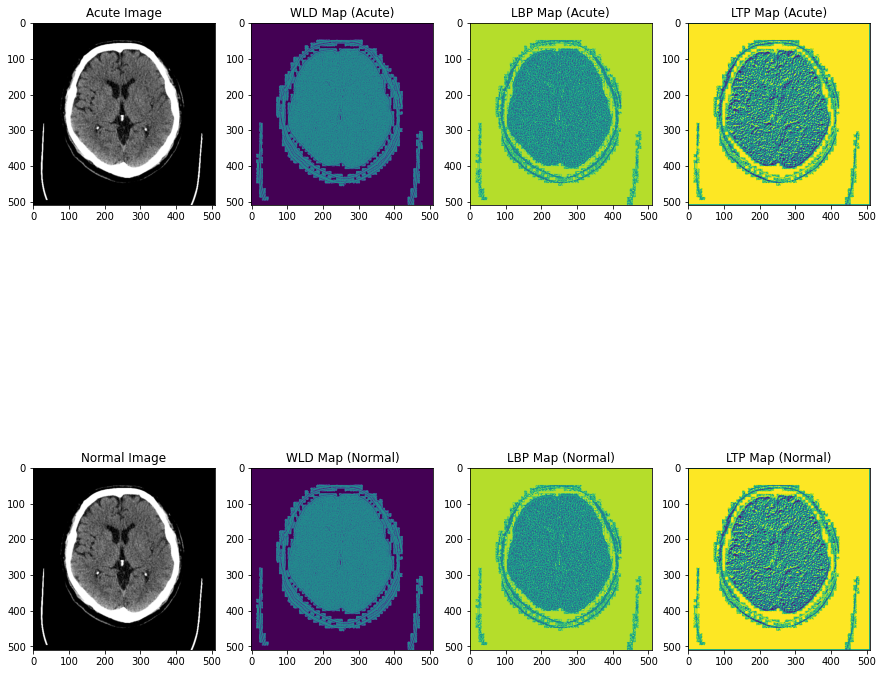

In [129]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import feature
from scipy import ndimage

def compute_lbp(image):
    lbp = feature.local_binary_pattern(image, P=8, R=1, method="uniform")
    return lbp

def compute_ltp(image):
    ltp = np.zeros_like(image, dtype=np.uint8)
    for i in range(1, image.shape[0] - 1):
        for j in range(1, image.shape[1] - 1):
            center = image[i, j]
            pattern = ""
            for x in range(-1, 2):
                for y in range(-1, 2):
                    if x == 0 and y == 0:
                        continue
                    if image[i + x, j + y] >= center:
                        pattern += "1"
                    else:
                        pattern += "0"
            ltp[i, j] = int(pattern, 2)
    return ltp

def compute_wld(image):
    dx = ndimage.sobel(image.astype(float), 0)
    dy = ndimage.sobel(image.astype(float), 1)
    
    magnitude = np.sqrt(dx**2 + dy**2)
    orientation = np.arctan2(dy, dx) * (180.0 / np.pi) % 180.0
    
    avg_magnitude = ndimage.uniform_filter(magnitude, size=3)
    differential_excitation = np.abs(np.log1p(magnitude / (avg_magnitude + 1e-5)))
    
    num_excitation_bins = 8
    num_orientation_bins = 36
    differential_excitation_bins = np.floor(differential_excitation * num_excitation_bins)
    orientation_bins = np.floor(orientation / (180.0 / num_orientation_bins))
    
    wld_map = 2 * num_orientation_bins * differential_excitation_bins + orientation_bins
    
    return wld_map

 

acute_image_thick = cv2.imread('C:/Users/Administrator/Downloads/Sample.jpg', cv2.IMREAD_GRAYSCALE)
normal_image_thick = cv2.imread('C:/Users/Administrator/Downloads/Sample.jpg', cv2.IMREAD_GRAYSCALE)

wld_map_acute = compute_wld(acute_image_thick)
lbp_map_acute = compute_lbp(acute_image_thick)
ltp_map_acute = compute_ltp(acute_image_thick)

wld_map_normal = compute_wld(normal_image_thick)
lbp_map_normal = compute_lbp(normal_image_thick)
ltp_map_normal = compute_ltp(normal_image_thick)
np.shape(ltp_map_normal)

# Plot maps
plt.figure(figsize=(15, 15))

plt.subplot(2, 4, 1)
plt.imshow(acute_image_thick, cmap='gray')
plt.title('Acute Image')

plt.subplot(2, 4, 2)
plt.imshow(wld_map_acute, cmap='viridis')
plt.title('WLD Map (Acute)')

plt.subplot(2, 4, 3)
plt.imshow(lbp_map_acute, cmap='viridis')
plt.title('LBP Map (Acute)')

plt.subplot(2, 4, 4)
plt.imshow(ltp_map_acute, cmap='viridis')
plt.title('LTP Map (Acute)')

# Plot maps for Normal Image
plt.subplot(2, 4, 5)
plt.imshow(normal_image_thick, cmap='gray')
plt.title('Normal Image')

plt.subplot(2, 4, 6)
plt.imshow(wld_map_normal, cmap='viridis')
plt.title('WLD Map (Normal)')

plt.subplot(2, 4, 7)
plt.imshow(lbp_map_normal, cmap='viridis')
plt.title('LBP Map (Normal)')

plt.subplot(2, 4, 8)
plt.imshow(ltp_map_normal, cmap='viridis')
plt.title('LTP Map (Normal)')

plt.show()


In [158]:
import cv2
import numpy as np

def weber_local_descriptor(image, k, sigma, gamma):
    # Convert the image to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Compute the gradient of the image
    grad_x = cv2.Sobel(gray_image, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray_image, cv2.CV_64F, 0, 1, ksize=3)
    
    # Compute the magnitude and orientation of the gradients
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    orientation = np.arccos(grad_y, grad_x)
    
    # Compute the Weber local descriptor
    descriptor = np.zeros_like(gray_image, dtype=np.float64)
    for i in range(gray_image.shape[0]):
        for j in range(gray_image.shape[1]):
            descriptor[i, j] = np.exp(-((magnitude[i, j] - k * gray_image[i, j])**2) / (2 * sigma**2)) * np.cos(gamma * (orientation[i, j] - np.pi/2))
    
    return descriptor

def generate_feature_map(descriptor):
    # Normalize the descriptor values to lie between 0 and 255
    feature_map = cv2.normalize(descriptor, None, 0, 255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    return feature_map

In [159]:
image=cv2.imread('C:/Users/Administrator/Downloads/Sample.jpg')
k = 0.5
sigma = 0.2
gamma = 2.0
feature_map=generate_feature_map(weber_local_descriptor(image[:,:], k, sigma, gamma))

C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_13012/320162654.py:14: RuntimeWarning: invalid value encountered in arccos
  orientation = np.arccos(grad_y, grad_x)


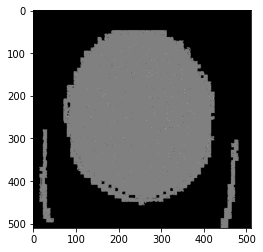

In [153]:
plt.imshow(feature_map, cmap='gray')